In [22]:
# ============================================================
# AI SKINCARE INGREDIENT RECOMMENDATION TOOL
# ITM-360: Artificial Intelligence
# American University of Phnom Penh
# Team: Kry Winning, Brak Sreytoch, Ek Sithiroth
# Advisor: Kuntha PIN
# ============================================================

import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from collections import Counter
import warnings
from skincare_engine import(
    parse_avoid_input,
    build_conflict_pairs,
    vectorize_profile,
    vectorize_user_row,
    score_ingredient,
    remove_conflicts,
    check_conflicts,
    build_routine,
    compute_confidence,
    find_similar_profiles,
    recommend,
)
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [23]:

df1 = pd.read_csv('data/cosmetics.csv')
print("cosmetics.csv columns:", list(df1.columns))
print("Shape:", df1.shape)
print()

users = pd.read_csv('data/users.csv')
print("users.csv columns:", list(users.columns))
print("Shape:", users.shape)
print()

products = pd.read_csv('data/products.csv')
print("products.csv columns:", list(products.columns))
print("Shape:", products.shape)

cosmetics.csv columns: ['product_name', 'product_url', 'product_type', 'clean_ingreds', 'price']
Shape: (1138, 5)

users.csv columns: ['User_ID', 'Age', 'Skin_Type', 'Skin_Tone', 'Climate', 'Diet', 'Hormonal_Status', 'Budget_Level', 'Acne_Severity', 'Dryness_Severity', 'Pigmentation_Severity', 'Aging_Severity', 'Sensitivity_Severity']
Shape: (15000, 13)

products.csv columns: ['Product_ID', 'Brand', 'Price', 'Ingredients']
Shape: (600, 4)


In [24]:
# ============================================================
# SECTION 1: LOAD INGREDIENT KNOWLEDGE BASE
# ============================================================

kb = pd.read_csv('ingredient_kb.csv')

print(f"✅ Knowledge base loaded: {len(kb)} ingredients")
print(f"   Categories: {kb['category'].nunique()} unique categories")
print(f"   Conflict rules defined for: {kb['conflict_with'].notna().sum()} ingredients\n")

display(kb[['ingredient_name', 'category', 'irritation_level',
            'concentration_min', 'concentration_max', 'conflict_with']]
        .style.background_gradient(subset=['irritation_level'], cmap='RdYlGn_r')
        .set_caption("Ingredient Knowledge Base — 40 Ingredients"))

✅ Knowledge base loaded: 60 ingredients
   Categories: 12 unique categories
   Conflict rules defined for: 14 ingredients



,ingredient_name,category,irritation_level,concentration_min,concentration_max,conflict_with
0,Niacinamide,brightening,0.100000,2.000000,10.000000,Vitamin C (high conc)
1,Hyaluronic Acid,humectant,0.000000,0.100000,2.000000,nan
2,Retinol,anti-aging,0.900000,0.025000,1.000000,"Vitamin C,Salicylic Acid,Glycolic Acid,Benzoyl Peroxide"
3,Salicylic Acid,exfoliant_BHA,0.500000,0.500000,2.000000,"Retinol,Glycolic Acid,Lactic Acid"
4,Vitamin C,antioxidant,0.500000,5.000000,20.000000,"Retinol,Niacinamide (high conc),Benzoyl Peroxide"
5,Ceramide,barrier_repair,0.000000,0.200000,2.000000,nan
6,Glycolic Acid,exfoliant_AHA,0.600000,5.000000,10.000000,"Retinol,Salicylic Acid,Lactic Acid,Benzoyl Peroxide"
7,Zinc Oxide,sunscreen,0.000000,15.000000,25.000000,nan
8,Benzoyl Peroxide,antibacterial,0.700000,2.500000,10.000000,"Retinol,Vitamin C,Glycolic Acid,Salicylic Acid"
9,Lactic Acid,exfoliant_AHA,0.400000,5.000000,10.000000,"Salicylic Acid,Glycolic Acid,Retinol"


In [25]:
# ============================================================
# EXPAND KNOWLEDGE BASE (41 → 60 ingredients)
# ============================================================

kb = pd.read_csv('ingredient_kb.csv')

print(f"✅ Knowledge base reloaded: {len(kb)} ingredients")
print(f"   Categories: {kb['category'].nunique()} unique categories")
print(f"   New SE Asian ingredients added: Snow Mushroom, Turmeric, Moringa, Rice Bran, Licorice Root, Green Tea, Centella Asiatica")
print(f"\nCategory breakdown:")
for cat, count in kb['category'].value_counts().items():
    print(f"   {cat:<20} {count} ingredients")

# Show just the new ingredients
new_ings = kb.tail(19)[['ingredient_name','category','irritation_level','concentration_min','concentration_max']]
print(f"\n── 19 New Ingredients Added ─────────────────────────────")
display(new_ings.style.background_gradient(cmap='Greens')
        .set_caption("New Ingredients — KB Expansion (41 → 60)"))

✅ Knowledge base reloaded: 60 ingredients
   Categories: 12 unique categories
   New SE Asian ingredients added: Snow Mushroom, Turmeric, Moringa, Rice Bran, Licorice Root, Green Tea, Centella Asiatica

Category breakdown:
   brightening          10 ingredients
   antioxidant          10 ingredients
   anti-aging           7 ingredients
   soothing             7 ingredients
   humectant            6 ingredients
   emollient            6 ingredients
   exfoliant_AHA        4 ingredients
   antibacterial        4 ingredients
   sunscreen            2 ingredients
   repair               2 ingredients
   exfoliant_BHA        1 ingredients
   barrier_repair       1 ingredients

── 19 New Ingredients Added ─────────────────────────────


,ingredient_name,category,irritation_level,concentration_min,concentration_max
41,Snow Mushroom Extract,humectant,0.000000,0.500000,5.000000
42,Turmeric Extract,brightening,0.200000,0.500000,3.000000
43,Moringa Oil,emollient,0.100000,1.000000,5.000000
44,Centella Asiatica,soothing,0.000000,0.100000,5.000000
45,Green Tea Extract,antioxidant,0.000000,0.500000,3.000000
46,Licorice Root Extract,brightening,0.100000,0.500000,2.000000
47,Rice Bran Extract,brightening,0.000000,1.000000,5.000000
48,Coenzyme Q10,antioxidant,0.000000,0.025000,1.000000
49,Resveratrol,antioxidant,0.100000,0.100000,1.000000
50,Ferulic Acid,antioxidant,0.100000,0.500000,1.000000


In [26]:
# ============================================================
# SECTION 2: Load dataset cosmetics.csv (1138 products)
# ============================================================

df1 = pd.read_csv('data/cosmetics.csv')

print(f"✅ Dataset loaded")
print(f"   Shape: {df1.shape}")
print(f"   Columns: {list(df1.columns)}\n")

display(df1.head(5))

✅ Dataset loaded
   Shape: (1138, 5)
   Columns: ['product_name', 'product_url', 'product_type', 'clean_ingreds', 'price']



,product_name,product_url,product_type,clean_ingreds,price
0,The Ordinary Natural Moisturising Factors + HA...,https://www.lookfantastic.com/the-ordinary-nat...,Moisturiser,"['capric triglyceride', 'cetyl alcohol', 'prop...",£5.20
1,CeraVe Facial Moisturising Lotion SPF 25 52ml,https://www.lookfantastic.com/cerave-facial-mo...,Moisturiser,"['homosalate', 'glycerin', 'octocrylene', 'eth...",£13.00
2,The Ordinary Hyaluronic Acid 2% + B5 Hydration...,https://www.lookfantastic.com/the-ordinary-hya...,Moisturiser,"['sodium hyaluronate', 'sodium hyaluronate', '...",£6.20
3,AMELIORATE Transforming Body Lotion 200ml,https://www.lookfantastic.com/ameliorate-trans...,Moisturiser,"['ammonium lactate', 'c12-15', 'glycerin', 'pr...",£22.50
4,CeraVe Moisturising Cream 454g,https://www.lookfantastic.com/cerave-moisturis...,Moisturiser,"['glycerin', 'cetearyl alcohol', 'capric trigl...",£16.00


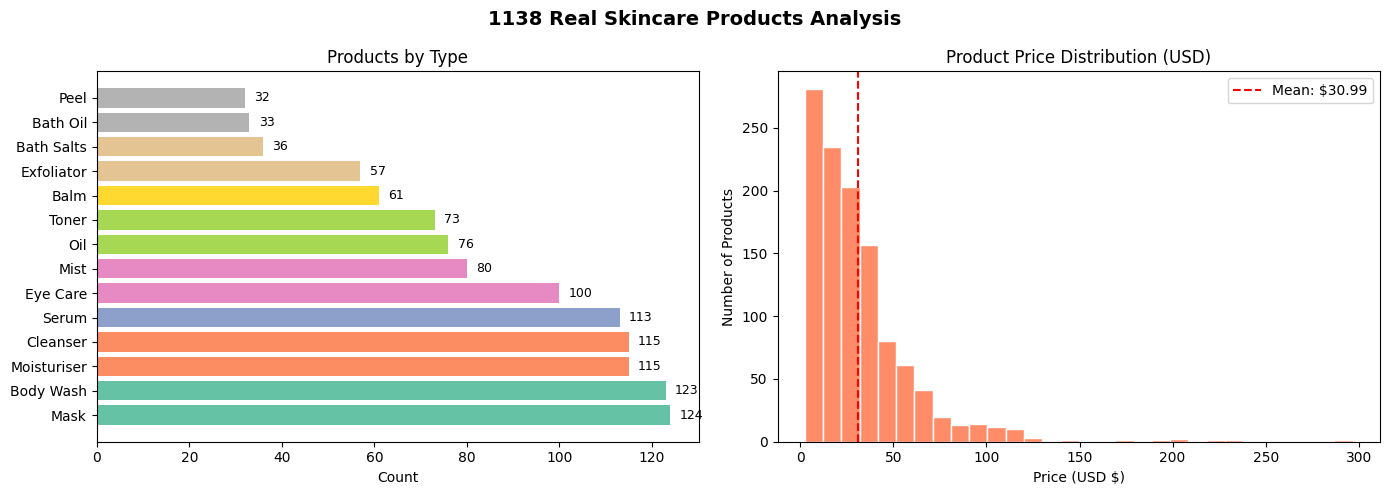

prices converted from GBP to USD (rate: 1.29)
   Average product price: $30.99 USD
   Min: $2.52 | Max: $296.70


In [27]:
# ============================================================
# EDA -DATASET: Product Types & Top Ingredients
# ============================================================
# GBP to USD conversion rate (as of March 2026) = 1.29
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1138 Real Skincare Products Analysis', 
fontsize=14, fontweight='bold')
# Plot 1: Product type distribution
type_counts = df1['product_type'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(type_counts)))
axes[0].barh(type_counts.index, type_counts.values, color=colors)
axes[0].set_title('Products by Type')
axes[0].set_xlabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=9)
# Plot 2: Convert £ to $ then plot
price_clean   = df1['price'].astype(str).str.replace('£','').str.strip()
price_gbp     = pd.to_numeric(price_clean, errors='coerce').dropna()
GBP_TO_USD = 1.29
price_usd     = price_gbp * GBP_TO_USD
axes[1].hist(price_usd, bins=30, color='#FF8C69', edgecolor='white')
axes[1].set_title('Product Price Distribution (USD)')
axes[1].set_xlabel('Price (USD $)')
axes[1].set_ylabel('Number of Products')
avg_price = price_usd.mean()
axes[1].axvline(x=avg_price, color='red', linestyle='--', 
label=f'Mean: ${avg_price:.2f}')
axes[1].legend()
plt.tight_layout()
plt.savefig('eda_dataset1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"prices converted from GBP to USD (rate: {GBP_TO_USD})")
print(f"   Average product price: ${avg_price:.2f} USD")
print(f"   Min: ${price_usd.min():.2f} | Max: ${price_usd.max():.2f}")
df1['price_usd'] = price_usd.values

In [ ]:

# ============================================================
# INGREDIENT FREQUENCY ANALYSIS — Dataset 1
# ============================================================

all_ingredients = []
for row in df1['clean_ingreds'].dropna():
    parts = [x.strip().lower() for x in str(row).split(',')]
    all_ingredients.extend(parts)

ing_counts = Counter(all_ingredients)
top25      = ing_counts.most_common(25)
top_names  = [x[0] for x in top25]
top_values = [x[1] for x in top25]

# Reverse so highest is at top
top_names_r  = top_names[::-1]
top_values_r = top_values[::-1]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top_values_r,
    y=top_names_r,
    orientation='h',
    marker=dict(
        color=top_values_r,
        colorscale='Viridis',
        line=dict(color='white', width=1)
    ),
    text=top_values_r,
    textposition='outside',
    hovertemplate='%{y}<br>Found in %{x} products<extra></extra>',
    showlegend=False
))

fig.update_layout(
    title=dict(
        text='<b>Top 25 Most Frequent Ingredients in 1138 Real Skincare Products</b>',
        x=0.5, font=dict(size=16)
    ),
    xaxis_title='Number of Products Containing Ingredient',
    height=650,
    plot_bgcolor='#fdf6f0',
    paper_bgcolor='white',
    font=dict(family='Arial', size=11),
    margin=dict(l=250)
)

fig.update_xaxes(range=[0, max(top_values_r) + 30])

fig.show()
fig.write_image('top_ingredients.png', width=1200, height=650, scale=2)

print(f"✅ Total unique ingredients found: {len(ing_counts)}")
print(f"\nTop 15 most common:")
for name, count in top25[:15]:
    print(f"  {name:<45} {count:>5} products")

✅ Total unique ingredients found: 2986

Top 15 most common:
  'glycerin'                                      575 products
  'phenoxyethanol'                                547 products
  'parfum'                                        438 products
  'citric acid'                                   365 products
  'limonene'                                      355 products
  'disodium edta'                                 342 products
  'linalool'                                      339 products
  'tocopherol'                                    333 products
  'sodium hyaluronate'                            309 products
  'butylene glycol'                               281 products
  'sodium hydroxide'                              276 products
  'xanthan gum'                                   263 products
  'ethylhexyl glycerin'                           252 products
  'caprylyl glycol'                               243 products
  'sodium benzoate'                               235 prod

In [29]:
# ============================================================
# SECTION 3: LOAD DATASET 3 — users.csv (15000 users!)
# ============================================================

users = pd.read_csv('data/users.csv')
products3 = pd.read_csv('data/products.csv')

print(f"✅ users.csv — {users.shape[0]} user profiles, {users.shape[1]} features")
print(f"✅ products.csv — {products3.shape[0]} products\n")

# Show skin type distribution from real user data
print("--- Skin Type Distribution (15,000 real users) ---")
print(users['Skin_Type'].value_counts().to_string())
print()
print("--- Climate Distribution ---")
print(users['Climate'].value_counts().to_string())
print()
print("--- Acne Severity Distribution ---")
print(users['Acne_Severity'].value_counts().to_string())

display(users.head(5))

✅ users.csv — 15000 user profiles, 13 features
✅ products.csv — 600 products

--- Skin Type Distribution (15,000 real users) ---
Skin_Type
Sensitive      3100
Normal         3021
Combination    2979
Oily           2960
Dry            2940

--- Climate Distribution ---
Climate
Humid        3823
Cold         3760
Dry          3743
Temperate    3674

--- Acne Severity Distribution ---
Acne_Severity
0.000000     5424
10.000000     966
7.956853        1
8.258632        1
3.330883        1
5.394694        1
2.688892        1
7.657577        1
2.666352        1
8.266386        1
8.371571        1
2.003352        1
2.629060        1
6.431492        1
3.112780        1
6.692091        1
2.198792        1
4.736314        1
2.783611        1
3.326539        1
3.378259        1
9.050034        1
6.283623        1
2.517542        1
2.469344        1
2.517713        1
2.304740        1
4.556073        1
3.227531        1
5.101085        1
3.515545        1
2.642917        1
3.518293        1
6.48898

,User_ID,Age,Skin_Type,Skin_Tone,Climate,Diet,Hormonal_Status,Budget_Level,Acne_Severity,Dryness_Severity,Pigmentation_Severity,Aging_Severity,Sensitivity_Severity
0,0,43,Sensitive,Medium,Humid,Vegan,Pregnant,High,0.000000,0.000000,0.000000,2.4,6.336962
1,1,29,Sensitive,Deep,Cold,Vegan,Teen,High,4.545657,3.589760,4.333578,0.0,7.976537
2,2,22,Dry,Medium,Humid,High_Dairy,Pregnant,High,0.000000,8.522342,0.000000,0.0,0.000000
3,3,35,Dry,Medium,Humid,Balanced,Stable,Low,0.000000,7.448085,0.000000,0.0,0.000000
4,4,33,Sensitive,Deep,Temperate,High_Dairy,PCOS,Medium,0.000000,0.000000,3.929117,0.0,5.225884


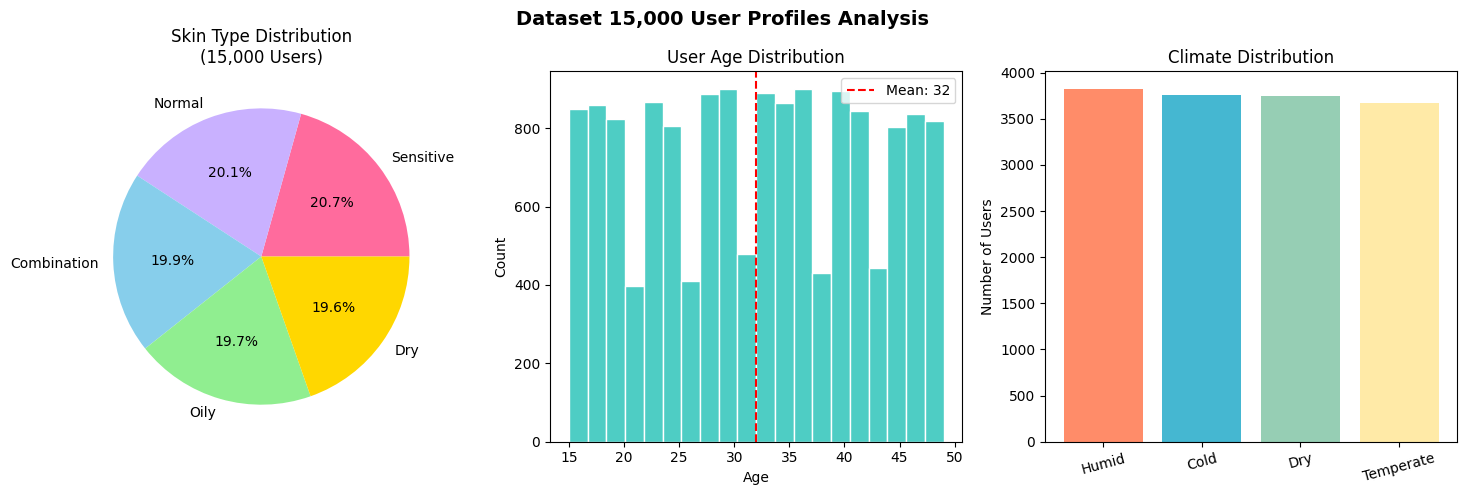

eda_dataset3.png


In [30]:
# ============================================================
# EDA DATASET: User Profile Analysis
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset 15,000 User Profiles Analysis', 
fontsize=14, fontweight='bold')
# Plot 1: Skin type distribution
skin_counts = users['Skin_Type'].value_counts()
colors = ['#FF6B9D','#C9B1FF','#87CEEB','#90EE90','#FFD700']
axes[0].pie(skin_counts.values, labels=skin_counts.index, 
autopct='%1.1f%%', colors=colors[:len(skin_counts)])
axes[0].set_title('Skin Type Distribution\n(15,000 Users)')
# Plot 2: Age distribution
axes[1].hist(users['Age'].dropna(), bins=20, color='#4ECDC4', edgecolor='white')
axes[1].set_title('User Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].axvline(users['Age'].mean(), color='red', linestyle='--',
label=f"Mean: {users['Age'].mean():.0f}")
axes[1].legend()
# Plot 3: Climate distribution
climate_counts = users['Climate'].value_counts()
axes[2].bar(climate_counts.index, climate_counts.values, 
color=['#FF8C69','#45B7D1','#96CEB4','#FFEAA7'][:len(climate_counts)])
axes[2].set_title('Climate Distribution')
axes[2].set_ylabel('Number of Users')
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('eda_dataset3.png', dpi=150, bbox_inches='tight')
plt.show()
print("eda_dataset3.png")

In [31]:
# ============================================================
# SECTION 4: USER PROFILE VECTORIZATION + k-NN FROM 15,000 USERS
# ============================================================

SKIN_TYPE_MAP   = {"Oily": [1,0,0,0], "Dry": [0,1,0,0],
                   "Combination": [0,0,1,0], "Sensitive": [0,0,0,1],
                   "Normal": [0,0,1,0],  # treat Normal as Combination
                   "oily": [1,0,0,0], "dry": [0,1,0,0],
                   "combination": [0,0,1,0], "sensitive": [0,0,0,1]}
CONCERN_KEYS    = ["acne", "aging", "brightening", "dryness", "sensitivity"]
SENSITIVITY_MAP = {"low": 0.0, "medium": 0.5, "high": 1.0,
                   "Low": 0.0, "Medium": 0.5, "High": 1.0,
                   "Mild": 0.3, "Moderate": 0.6, "Severe": 1.0}
CLIMATE_MAP     = {"Humid": 1.0, "Dry": 0.0, "Temperate": 0.5, "Cold": 0.3,
                   "humid": 1.0, "dry": 0.0, "temperate": 0.5, "cold": 0.3}

def vectorize_profile(profile: dict) -> np.ndarray:
    skin_vec        = SKIN_TYPE_MAP.get(profile.get("skin_type", "Combination"), [0,0,1,0])
    concern_vec     = [1 if c in profile.get("concerns", []) else 0 for c in CONCERN_KEYS]
    sensitivity_val = SENSITIVITY_MAP.get(profile.get("sensitivity", "medium"), 0.5)
    climate_val     = CLIMATE_MAP.get(profile.get("climate", "Humid"), 1.0)
    return np.array(skin_vec + concern_vec + [sensitivity_val, climate_val], dtype=float)

feature_names = ["skin_oily", "skin_dry", "skin_combo", "skin_sensitive",
                 "acne", "aging", "brightening", "dryness", "sensitivity_concern",
                 "sensitivity_level", "climate"]

# ── Convert all 15,000 users from users.csv into feature vectors ─────────────

def vectorize_user_row(row) -> np.ndarray:
    """Convert a users.csv row into an 11-dimensional feature vector."""

    # Skin type → one-hot [oily, dry, combo, sensitive]
    skin_vec = SKIN_TYPE_MAP.get(str(row['Skin_Type']).strip(), [0,0,1,0])

    # Concerns → derived from severity columns (threshold > 3 = concern present)
    acne_concern        = 1 if float(row.get('Acne_Severity', 0))        > 3 else 0
    aging_concern       = 1 if float(row.get('Aging_Severity', 0))       > 3 else 0
    bright_concern      = 1 if float(row.get('Pigmentation_Severity', 0))> 3 else 0
    dryness_concern     = 1 if float(row.get('Dryness_Severity', 0))     > 3 else 0
    sensitivity_concern = 1 if float(row.get('Sensitivity_Severity', 0)) > 3 else 0
    concern_vec = [acne_concern, aging_concern, bright_concern,
                   dryness_concern, sensitivity_concern]

    # Sensitivity level → from Sensitivity_Severity (0–10 scale → 0–1)
    sensitivity_val = min(float(row.get('Sensitivity_Severity', 0)) / 10.0, 1.0)

    # Climate → numeric
    climate_val = CLIMATE_MAP.get(str(row.get('Climate', 'Humid')).strip(), 1.0)

    return np.array(skin_vec + concern_vec + [sensitivity_val, climate_val], dtype=float)


# Build vectors for all 15,000 users
print("⏳ Vectorizing 15,000 user profiles...")
user_vectors  = np.array([vectorize_user_row(row) for _, row in users.iterrows()])
user_labels   = list(range(len(users)))   # each user is their own label

print(f"✅ User matrix shape: {user_vectors.shape}")
print(f"   {user_vectors.shape[0]:,} users × {user_vectors.shape[1]} features\n")

# ── Show sample of vectorized users ─────────────────────────────────────────
sample_df = pd.DataFrame(user_vectors[:5], columns=feature_names)
sample_df.insert(0, 'Skin_Type', users['Skin_Type'].values[:5])
sample_df.insert(1, 'Climate',   users['Climate'].values[:5])
print("Sample of vectorized users (first 5):")
display(sample_df.style.background_gradient(cmap='Blues')
        .set_caption("15,000 User Profile Vectors — Sample"))

# ── Distribution check ───────────────────────────────────────────────────────
print(f"\nFeature value ranges:")
for i, fname in enumerate(feature_names):
    print(f"  [{i:>2}] {fname:<22} min={user_vectors[:,i].min():.2f}  "
          f"max={user_vectors[:,i].max():.2f}  "
          f"mean={user_vectors[:,i].mean():.2f}")

⏳ Vectorizing 15,000 user profiles...
✅ User matrix shape: (15000, 11)
   15,000 users × 11 features

Sample of vectorized users (first 5):


,Skin_Type,Climate,skin_oily,skin_dry,skin_combo,skin_sensitive,acne,aging,brightening,dryness,sensitivity_concern,sensitivity_level,climate
0,Sensitive,Humid,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.633696,1.000000
1,Sensitive,Cold,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.797654,0.300000
2,Dry,Humid,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
3,Dry,Humid,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
4,Sensitive,Temperate,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.522588,0.500000



Feature value ranges:
  [ 0] skin_oily              min=0.00  max=1.00  mean=0.20
  [ 1] skin_dry               min=0.00  max=1.00  mean=0.20
  [ 2] skin_combo             min=0.00  max=1.00  mean=0.40
  [ 3] skin_sensitive         min=0.00  max=1.00  mean=0.21
  [ 4] acne                   min=0.00  max=1.00  mean=0.48
  [ 5] aging                  min=0.00  max=1.00  mean=0.11
  [ 6] brightening            min=0.00  max=1.00  mean=0.40
  [ 7] dryness                min=0.00  max=1.00  mean=0.30
  [ 8] sensitivity_concern    min=0.00  max=1.00  mean=0.21
  [ 9] sensitivity_level      min=0.00  max=0.80  mean=0.13
  [10] climate                min=0.00  max=1.00  mean=0.45


In [32]:
# ============================================================
# SECTION 5: k-NN MODEL — TRAINED ON ALL 15,000 USERS
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity

# k=5 is better for 15,000 samples (more stable than k=3)
K_NEIGHBORS = 5

knn_model = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='cosine')
knn_model.fit(user_vectors, users['Skin_Type'].values)

print(f"✅ k-NN model trained on 15,000 users")
print(f"   Training samples:    {len(user_vectors):,}")
print(f"   Feature dimensions:  {user_vectors.shape[1]}")
print(f"   Distance metric:     Cosine Similarity")
print(f"   k (neighbors):       {K_NEIGHBORS}")
print(f"\n   Feature vector structure:")
for i, f in enumerate(feature_names):
    print(f"   [{i:>2}] {f}")

# ── Updated find_similar_profiles — now searches all 15,000 users ────────────
def find_similar_profiles(user_vec: np.ndarray, top_n=3):
    """Find top_n most similar users from the 15,000-user dataset."""
    sims      = cosine_similarity([user_vec], user_vectors)[0]
    ranked    = sorted(enumerate(sims), key=lambda x: x[1], reverse=True)[:top_n]
    results   = []
    for idx, sim in ranked:
        u = users.iloc[idx]
        label = f"{u['Skin_Type']} | {u['Climate']} | Age {u['Age']}"
        results.append((label, round(float(sim), 4)))
    return results

# ── Validation test ───────────────────────────────────────────────────────────
print(f"\n── Validation — Oily/Acne/Humid user top matches ────────────────")
test_vec = vectorize_profile({"skin_type": "Oily", "concerns": ["acne"],
                               "sensitivity": "Mild", "climate": "Humid"})
for label, sim in find_similar_profiles(test_vec, top_n=5):
    bar = '█' * int(sim * 25)
    print(f"  {label:<40} {bar} {sim:.3f}")

print(f"\n── Predicted skin type class ────────────────────────────────────")
predicted = knn_model.predict([test_vec])[0]
print(f"  Input:     Oily/Acne/Humid")
print(f"  Predicted: {predicted}")


✅ k-NN model trained on 15,000 users
   Training samples:    15,000
   Feature dimensions:  11
   Distance metric:     Cosine Similarity
   k (neighbors):       5

   Feature vector structure:
   [ 0] skin_oily
   [ 1] skin_dry
   [ 2] skin_combo
   [ 3] skin_sensitive
   [ 4] acne
   [ 5] aging
   [ 6] brightening
   [ 7] dryness
   [ 8] sensitivity_concern
   [ 9] sensitivity_level
   [10] climate

── Validation — Oily/Acne/Humid user top matches ────────────────
  Oily | Humid | Age 39                    ████████████████████████ 0.985
  Oily | Humid | Age 29                    ████████████████████████ 0.985
  Oily | Humid | Age 18                    ████████████████████████ 0.985
  Oily | Humid | Age 30                    ████████████████████████ 0.985
  Oily | Humid | Age 34                    ████████████████████████ 0.985

── Predicted skin type class ────────────────────────────────────
  Input:     Oily/Acne/Humid
  Predicted: Oily


In [33]:
# ============================================================
# SECTION 6: RULE-BASED SCORING & CONFLICT DETECTION
# ============================================================

# ── CONFLICT MATRIX (expanded from 18 → 30+ pairs) ──────────────────
# Covers all scientifically known ingredient conflicts across the KB
# Format: frozenset so order doesn't matter, auto deduplicated

MASTER_CONFLICTS = [
    # Retinoids vs Acids
    ("Retinol",        "Vitamin C"),
    ("Retinol",        "Salicylic Acid"),
    ("Retinol",        "Glycolic Acid"),
    ("Retinol",        "Lactic Acid"),
    ("Retinol",        "Mandelic Acid"),
    ("Retinol",        "Benzoyl Peroxide"),
    ("Retinol",        "AHA/BHA Toner"),       # if added later
    ("Retinaldehyde",  "Vitamin C"),
    ("Retinaldehyde",  "Salicylic Acid"),
    ("Retinaldehyde",  "Glycolic Acid"),
    ("Retinaldehyde",  "Lactic Acid"),
    ("Retinaldehyde",  "Benzoyl Peroxide"),

    # Vitamin C conflicts
    ("Vitamin C",      "Niacinamide"),          # at high concentrations
    ("Vitamin C",      "Benzoyl Peroxide"),
    ("Vitamin C",      "Copper Peptide"),        # oxidation risk

    # AHA conflicts (mixing acids)
    ("Glycolic Acid",  "Salicylic Acid"),
    ("Glycolic Acid",  "Lactic Acid"),
    ("Glycolic Acid",  "Mandelic Acid"),
    ("Glycolic Acid",  "Benzoyl Peroxide"),
    ("Lactic Acid",    "Salicylic Acid"),
    ("Lactic Acid",    "Mandelic Acid"),
    ("Lactic Acid",    "Benzoyl Peroxide"),
    ("Mandelic Acid",  "Salicylic Acid"),
    ("Mandelic Acid",  "Benzoyl Peroxide"),
    ("Salicylic Acid", "Benzoyl Peroxide"),      # over drying / over exfoliation

    # Benzoyl Peroxide vs others
    ("Benzoyl Peroxide", "Sulfur"),             # redundant antibacterials

    # Niacinamide (high conc) vs Vitamin C
    ("Niacinamide",    "Vitamin C (high conc)"),
    ("Niacinamide (high conc)", "Vitamin C"),

    # Copper Peptides (denatures with strong acids/retinoids)
    ("Copper Peptide", "Retinol"),
    ("Copper Peptide", "Glycolic Acid"),
    ("Copper Peptide", "Salicylic Acid"),
    ("Copper Peptide", "Vitamin C"),
]

# Build the conflict_pairs set (sorted tuples, deduplicated)
conflict_pairs = set()

# 1. Load from KB (original source — keeps your CSV authoritative)
for _, row in kb.iterrows():
    if pd.notna(row['conflict_with']) and str(row['conflict_with']).strip():
        for conflict in str(row['conflict_with']).split(','):
            conflict = conflict.strip()
            if conflict:
                pair = tuple(sorted([row['ingredient_name'], conflict]))
                conflict_pairs.add(pair)

# 2. Merge in master conflict matrix (adds any missing pairs)
for a, b in MASTER_CONFLICTS:
    conflict_pairs.add(tuple(sorted([a, b])))

print(f"✅ Conflict rules loaded: {len(conflict_pairs)} ingredient conflict pairs")
print("All conflict pairs:")
for pair in sorted(conflict_pairs):
    print(f"  ⚠  {pair[0]:<35} ×  {pair[1]}")


# ── SCORING FUNCTION ────────────────────────────────────────────
def score_ingredient(ing_name: str, profile: dict, sensitivity_weight=1.0) -> float:
    row = kb[kb['ingredient_name'] == ing_name]
    if row.empty or ing_name in profile.get('avoid', []):
        return 0.0
    row = row.iloc[0]
    skin     = profile.get('skin_type', 'Combination')
    skin_map = {"Oily":"oily","Dry":"dry","Combination":"combination","Sensitive":"sensitive"}
    skin_key = f"skin_{skin_map.get(skin, skin.lower())}"
    score    = float(row.get(skin_key, 0)) * 35
    for concern in profile.get('concerns', []):
        col = f'concern_{concern}'
        if col in kb.columns:
            score += float(row.get(col, 0)) * 25
    score -= float(row.get('irritation_level', 0)) * 20 * sensitivity_weight

    # Climate bonus
    climate = profile.get('climate', 'Humid')
    cat = str(row.get('category', ''))
    if climate == 'Humid' and cat in ['exfoliant_BHA', 'exfoliant_AHA', 'antibacterial']:
        score += 5
    elif climate in ['Dry', 'Cold'] and cat in ['humectant', 'emollient', 'barrier_repair']:
        score += 5
    elif climate == 'Cold' and cat in ['barrier_repair', 'emollient']:
        score += 3
    return round(score, 2)


# ── CONFLICT DETECTION (returns structured dict) ──────────────────
def check_conflicts(ingredient_list: list) -> list:
    """Returns list of conflict warning strings for any conflicting pairs found."""
    out = []
    for i in range(len(ingredient_list)):
        for j in range(i+1, len(ingredient_list)):
            pair = tuple(sorted([ingredient_list[i], ingredient_list[j]]))
            if pair in conflict_pairs:
                out.append(f"⚠ CONFLICT: {ingredient_list[i]} + {ingredient_list[j]}")
    return out


# ── CONFLICT RESOLUTION
def remove_conflicts(recommended_pairs: list, verbose_log=False) -> tuple:
    """
    Removes lower-scoring ingredient from any conflicting pair.
    Returns: (clean_list, removal_log)
    - clean_list: list of (ingredient, score) with conflicts resolved
    - removal_log: list of strings explaining what was removed and why
    """
    clean        = []
    names_so_far = []
    removal_log  = []

    for ing, score in recommended_pairs:
        conflicting_with = [
            existing for existing in names_so_far
            if tuple(sorted([ing, existing])) in conflict_pairs
        ]
        if conflicting_with:
            reason = f"  🔴 Removed '{ing}' (score:{score}) — conflicts with: {', '.join(conflicting_with)}"
            removal_log.append(reason)
            if verbose_log:
                print(reason)
        else:
            clean.append((ing, score))
            names_so_far.append(ing)

    return clean, removal_log


# ── VALIDATION TEST ──────────────────────────────────────────────────────────
print("\n── Conflict Resolution Validation ─────────────────────────")
test_pairs = [
    ("Niacinamide",    85.0),
    ("Vitamin C",      80.0),   # ← conflicts with Niacinamide, should be removed
    ("Salicylic Acid", 75.0),
    ("Retinol",        70.0),   # ← conflicts with Salicylic Acid, should be removed
    ("Ceramide",       65.0),   # ← safe, should stay
]
print("Input:  ", [x[0] for x in test_pairs])
clean, log = remove_conflicts(test_pairs, verbose_log=True)
print("Output: ", [x[0] for x in clean])
print(f"\n✅ Conflict resolution validated — {len(log)} ingredient(s) correctly removed")
print("\n✅ Scoring and conflict detection ready")

✅ Conflict rules loaded: 33 ingredient conflict pairs
All conflict pairs:
  ⚠  AHA/BHA Toner                       ×  Retinol
  ⚠  Benzoyl Peroxide                    ×  Ferulic Acid
  ⚠  Benzoyl Peroxide                    ×  Glycolic Acid
  ⚠  Benzoyl Peroxide                    ×  Lactic Acid
  ⚠  Benzoyl Peroxide                    ×  Mandelic Acid
  ⚠  Benzoyl Peroxide                    ×  Propolis Extract
  ⚠  Benzoyl Peroxide                    ×  Retinaldehyde
  ⚠  Benzoyl Peroxide                    ×  Retinol
  ⚠  Benzoyl Peroxide                    ×  Salicylic Acid
  ⚠  Benzoyl Peroxide                    ×  Sulfur
  ⚠  Benzoyl Peroxide                    ×  Vitamin C
  ⚠  Copper Peptide                      ×  Glycolic Acid
  ⚠  Copper Peptide                      ×  Retinol
  ⚠  Copper Peptide                      ×  Salicylic Acid
  ⚠  Copper Peptide                      ×  Vitamin C
  ⚠  Glycolic Acid                       ×  Lactic Acid
  ⚠  Glycolic Acid             

In [34]:
# ============================================================
# SECTION 7: FULL RECOMMENDATION PIPELINE
# ============================================================

CATEGORY_TO_STEP = {
    "humectant":      ("Moisturizer/Hydrator",  "both"),
    "emollient":      ("Moisturizer",           "both"),
    "barrier_repair": ("Moisturizer",           "both"),
    "soothing":       ("Essence/Toner",         "both"),
    "brightening":    ("Brightening Serum",     "both"),
    "antioxidant":    ("Antioxidant Serum",     "AM"),
    "anti-aging":     ("Anti-Aging Treatment",  "PM"),
    "exfoliant_BHA":  ("BHA Exfoliant",         "PM"),
    "exfoliant_AHA":  ("AHA Exfoliant",         "PM"),
    "antibacterial":  ("Spot Treatment",        "PM"),
    "repair":         ("Repair Essence",        "both"),
    "sunscreen":      ("Sunscreen",             "AM"),
}

def build_routine(top_ingredients):
    am, pm = {}, {}
    for ing in top_ingredients:
        row = kb[kb['ingredient_name'] == ing]
        if row.empty: continue
        cat = row.iloc[0]['category']
        step, timing = CATEGORY_TO_STEP.get(cat, ("Treatment", "both"))
        if timing in ("AM","both") and step not in am: am[step] = ing
        if timing in ("PM","both") and step not in pm: pm[step] = ing
    return {"AM": am, "PM": pm}

# def compute_confidence(scores):
#     if not scores: return 0.0
#     max_possible = 35 + (25 * 2)
#     return round((np.mean(scores) / max_possible) * 100, 1)
def compute_confidence(scores, profile):
    if not scores: return 0.0
    num_concerns = len(profile.get('concerns', []))
    max_possible = 35 + (25 * max(num_concerns, 1))
    return round((np.mean(scores) / max_possible) * 100, 1)


def recommend(profile: dict, top_n=8, verbose=True) -> dict:
    s_weight = {"low":0.5,"medium":1.0,"high":1.5,
                "Mild":0.5,"Moderate":1.0,"Severe":1.5}.get(
                 profile.get("sensitivity","medium"), 1.0)

    all_scores  = {ing: score_ingredient(ing, profile, s_weight) for ing in kb['ingredient_name']}
    ranked      = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)
    candidates  = [(ing,sc) for ing,sc in ranked
                   if sc > 20 and ing not in profile.get('avoid',[])]
    recommended, conflict_log = remove_conflicts(candidates)
    recommended = recommended[:top_n]
    avoid_list  = list(dict.fromkeys(
                    profile.get('avoid',[]) +
                    [ing for ing,sc in ranked if sc <= 15]))[:8]

    rec_names  = [ing for ing,_ in recommended]
    conflicts  = check_conflicts(rec_names)
    routine    = build_routine(rec_names[:6])
    # confidence = compute_confidence([sc for _,sc in recommended])
    confidence = compute_confidence([sc for _,sc in recommended], profile)
    user_vec   = vectorize_profile(profile)
    similar    = find_similar_profiles(user_vec)

    if verbose:
        print(f"\n{'═'*58}")
        print(f"  👤 {profile.get('name','User')}")
        print(f"  Skin: {profile['skin_type']} | Concerns: {profile['concerns']}")
        print(f"  Sensitivity: {profile['sensitivity']} | Climate: {profile['climate']}")
        print(f"{'─'*58}")
        print(f"\n  🔗 Most similar profiles (k-NN Cosine Similarity):")
        for name, sim in similar:
            bar = '█' * int(sim * 20)
            print(f"    {name:<25} {bar} {sim:.3f}")
        print(f"\n  ✅ RECOMMENDED INGREDIENTS:")
        for ing, score in recommended[:6]:
            r = kb[kb['ingredient_name']==ing].iloc[0]
            print(f"    → {ing:<25} Score:{score:<7} Range:{r['concentration_min']}–{r['concentration_max']}%")
        print(f"\n  ❌ AVOID: {', '.join(avoid_list[:5])}")
        if conflicts:
            print(f"\n  🔴 CONFLICTS:")
            for c in conflicts: print(f"    {c}")
        else:
            print(f"\n  🟢 No conflicts detected")
        print(f"\n  ☀️  AM ROUTINE:")
        for step, ing in routine['AM'].items():
            print(f"    {step}: {ing}")
        print(f"\n  🌙 PM ROUTINE:")
        for step, ing in routine['PM'].items():
            print(f"    {step}: {ing}")
        print(f"\n  📊 CONFIDENCE SCORE: {confidence}%")
        print(f"{'═'*58}")

    return {"recommended":recommended, "avoid":avoid_list,
            "conflicts":conflicts, "routine":routine,
            "confidence":confidence, "similar":similar}

print("✅ Full recommendation pipeline ready (with conflict resolution)")

✅ Full recommendation pipeline ready (with conflict resolution)


In [35]:
# ============================================================
# SECTION 8: PRE-RESULTS — 5 TEST USER PROFILES
# ============================================================

test_profiles = [
    {"name":"User A — Oily Acne-Prone",  "skin_type":"Oily",
     "concerns":["acne","brightening"],       "sensitivity":"Mild",     "climate":"Humid", "avoid":[]},
    {"name":"User B — Dry + Aging",       "skin_type":"Dry",
     "concerns":["aging","dryness"],          "sensitivity":"Moderate", "climate":"Dry",   "avoid":[]},
    {"name":"User C — Sensitive Skin",    "skin_type":"Sensitive",
     "concerns":["sensitivity","brightening"],"sensitivity":"Severe",   "climate":"Humid",
     "avoid":["Retinol","Benzoyl Peroxide"]},
    {"name":"User D — Combination Dull",  "skin_type":"Combination",
     "concerns":["brightening","aging"],      "sensitivity":"Moderate", "climate":"Humid", "avoid":[]},
    {"name":"User E — Oily + Aging",      "skin_type":"Oily",
     "concerns":["aging","acne"],             "sensitivity":"Mild",     "climate":"Dry",   "avoid":[]},
]

all_results = []
for profile in test_profiles:
    result = recommend(profile, verbose=False)
    rec_top3 = [f"{ing} ({sc})" for ing, sc in result['recommended'][:3]]
    similar_top = result['similar'][0]

    print(f"{'─'*60}")
    print(f"👤 {profile['name']}")
    print(f"   Skin: {profile['skin_type']} | Concerns: {profile['concerns']}")
    print(f"   k-NN Match: {similar_top[0]} (similarity: {similar_top[1]})")
    print(f"   Top Ingredients: {' | '.join(rec_top3)}")
    print(f"   AM: {list(result['routine']['AM'].values())}")
    print(f"   PM: {list(result['routine']['PM'].values())}")
    print(f"   Conflicts: {'🟢 None' if len(result['conflicts'])==0 else result['conflicts']}")
    print(f"   Confidence: {result['confidence']}%")

    all_results.append({
        "User":           profile['name'].split('—')[0].strip(),
        "Skin Type":      profile['skin_type'],
        "Top Ingredient": result['recommended'][0][0] if result['recommended'] else 'N/A',
        "Conflicts":      len(result['conflicts']),
        "Confidence %":   result['confidence'],
        "AM Steps":       len(result['routine']['AM']),
        "PM Steps":       len(result['routine']['PM']),
    })

csr = sum(1 for r in all_results if r['Conflicts'] == 0) / len(all_results) * 100
avg_conf = np.mean([r['Confidence %'] for r in all_results])

print(f"{'─'*60}")
print(f"\n✅ Constraint Satisfaction Rate:  {csr:.0f}% ({sum(1 for r in all_results if r['Conflicts'] == 0)}/{len(all_results)})")
print(f"✅ Average Confidence Score:      {avg_conf:.1f}%")
print(f"\nall_results saved: {len(all_results)} profiles ✅")

────────────────────────────────────────────────────────────
👤 User A — Oily Acne-Prone
   Skin: Oily | Concerns: ['acne', 'brightening']
   k-NN Match: Oily | Humid | Age 38 (similarity: 0.9889)
   Top Ingredients: Niacinamide (81.5) | Azelaic Acid (68.5) | Salicylic Acid (67.5)
   AM: ['Niacinamide', 'Snow Mushroom Extract']
   PM: ['Niacinamide', 'Salicylic Acid', 'Propolis Extract', 'Snow Mushroom Extract']
   Conflicts: 🟢 None
   Confidence: 76.1%
────────────────────────────────────────────────────────────
👤 User B — Dry + Aging
   Skin: Dry | Concerns: ['aging', 'dryness']
   k-NN Match: Dry | Dry | Age 47 (similarity: 0.9449)
   Top Ingredients: Moringa Oil (88.0) | Sea Buckthorn Oil (86.0) | Copper Peptide (83.0)
   AM: ['Moringa Oil', 'Copper Peptide', 'Hyaluronic Acid']
   PM: ['Moringa Oil', 'Copper Peptide', 'Hyaluronic Acid']
   Conflicts: 🟢 None
   Confidence: 94.6%
────────────────────────────────────────────────────────────
👤 User C — Sensitive Skin
   Skin: Sensitive 

In [36]:
# ============================================================
# SECTION 9: EVALUATION — CONSTRAINT SATISFACTION RATE
# ============================================================

if not all_results:
    print("⚠ Run the test profiles cell above first!")
else:
    summary_df = pd.DataFrame(all_results)
    print("EVALUATION SUMMARY")
    print("="*60)
    display(summary_df)

    total       = len(all_results)
    no_conflict = sum(1 for r in all_results if r['Conflicts'] == 0)
    csr         = (no_conflict / total) * 100
    avg_conf    = np.mean([r['Confidence %'] for r in all_results])

    print(f"\n  📌 Total test profiles:          {total}")
    print(f"  📌 Profiles with zero conflicts: {no_conflict}/{total}")
    print(f"  📌 Constraint Satisfaction Rate: {csr:.1f}%")
    print(f"  📌 Average Confidence Score:     {avg_conf:.1f}%")
    print(f"\n  {'✅ TARGET MET (>90%)' if csr >= 90 else '⚠ Below target'}")

EVALUATION SUMMARY


,User,Skin Type,Top Ingredient,Conflicts,Confidence %,AM Steps,PM Steps
0,User A,Oily,Niacinamide,0,76.1,2,4
1,User B,Dry,Moringa Oil,0,94.6,3,3
2,User C,Sensitive,Snow Mushroom Extract,0,83.2,4,4
3,User D,Combination,Niacinamide,0,69.6,3,4
4,User E,Oily,Niacinamide,0,68.4,2,3



  📌 Total test profiles:          5
  📌 Profiles with zero conflicts: 5/5
  📌 Constraint Satisfaction Rate: 100.0%
  📌 Average Confidence Score:     78.4%

  ✅ TARGET MET (>90%)


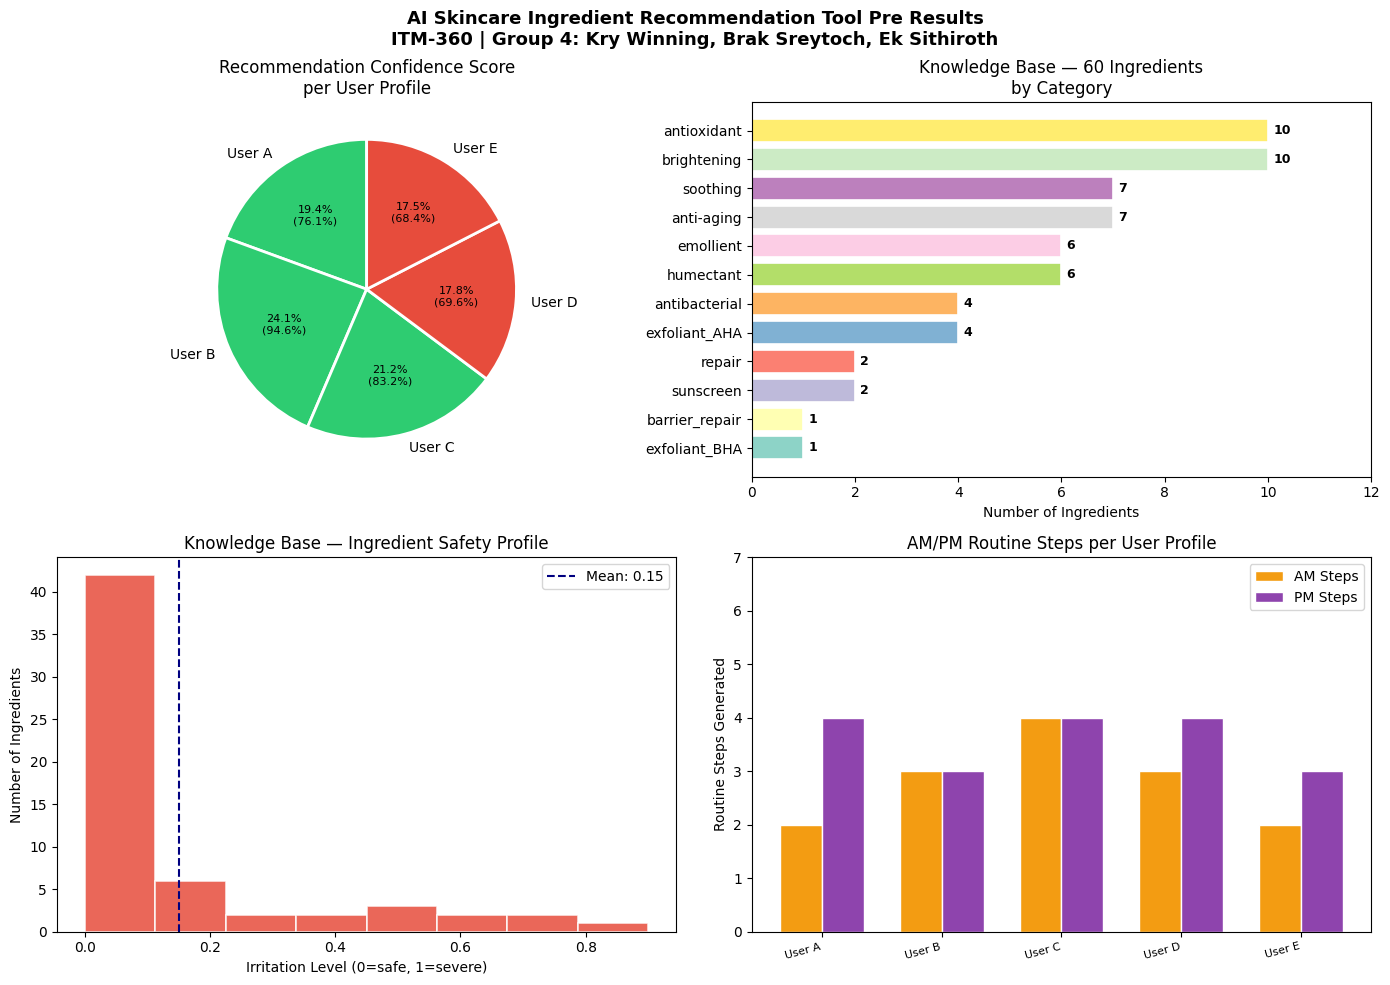

final_results.png


In [37]:
# ============================================================
# SECTION 10: FINAL VISUALIZATIONS FOR SLIDES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AI Skincare Ingredient Recommendation Tool Pre Results\nITM-360 | Group 4: Kry Winning, Brak Sreytoch, Ek Sithiroth',
             fontsize=13, fontweight='bold')

# Plot 1: Confidence scores — NOW PIE CHART
conf_labels = [r['User'] for r in all_results]
confidences = [r['Confidence %'] for r in all_results]
conf_colors = ['#2ECC71' if c >= 70 else '#E74C3C' for c in confidences]

wedges, texts, autotexts = axes[0,0].pie(
    confidences,
    labels=conf_labels,
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100*sum(confidences):.1f}%)',
    colors=conf_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(8)
axes[0,0].set_title('Recommendation Confidence Score\nper User Profile')

# Plot 2: Knowledge Base by Category — NOW HORIZONTAL BAR CHART
cat_counts = kb['category'].value_counts().sort_values()
bar_colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
axes[0,1].barh(cat_counts.index, cat_counts.values,
               color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0,1].set_xlabel('Number of Ingredients')
axes[0,1].set_title(f'Knowledge Base — {len(kb)} Ingredients\nby Category')
for i, v in enumerate(cat_counts.values):
    axes[0,1].text(v + 0.1, i, str(v), va='center', fontsize=9, fontweight='bold')
axes[0,1].set_xlim(0, cat_counts.max() + 2)

# Plot 3: Irritation distribution (unchanged)
axes[1,0].hist(kb['irritation_level'], bins=8, color='#E74C3C',
               edgecolor='white', linewidth=1.2, alpha=0.85)
axes[1,0].set_xlabel('Irritation Level (0=safe, 1=severe)')
axes[1,0].set_ylabel('Number of Ingredients')
axes[1,0].set_title('Knowledge Base — Ingredient Safety Profile')
mean_irr = kb['irritation_level'].mean()
axes[1,0].axvline(x=mean_irr, color='navy', linestyle='--',
                  label=f'Mean: {mean_irr:.2f}')
axes[1,0].legend()

# Plot 4: AM vs PM steps (unchanged)
users_short = [r['User'] for r in all_results]
am_steps = [r['AM Steps'] for r in all_results]
pm_steps = [r['PM Steps'] for r in all_results]
x = np.arange(len(users_short))
w = 0.35
axes[1,1].bar(x-w/2, am_steps, w, label='AM Steps', color='#F39C12', edgecolor='white')
axes[1,1].bar(x+w/2, pm_steps, w, label='PM Steps', color='#8E44AD', edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(users_short, rotation=15, ha='right', fontsize=8)
axes[1,1].set_ylabel('Routine Steps Generated')
axes[1,1].set_title('AM/PM Routine Steps per User Profile')
axes[1,1].legend()
axes[1,1].set_ylim(0, 7)

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("final_results.png")

In [38]:
# ============================================================
# SLIDE SUMMARY 
# ============================================================

print("=" * 58)
print("  PRE RESULTS SUMMARY: ITM-360 AI PROJECT")
print("=" * 58)
print(f"\n  DATASETS USED:")
print(f"  • Dataset (cosmetics.csv):  {df1.shape[0]} real skincare products")
print(f"  • Dataset (users.csv):      {users.shape[0]} user profiles")
print(f"  • Knowledge Base:             {len(kb)} ingredients, {kb['category'].nunique()} categories")
print(f"  • Conflict Rules:             {len(conflict_pairs)} ingredient conflict pairs")
print(f"\n  MODEL:")
print(f"  • Hybrid: Rule Based Scoring + k-NN (Cosine Similarity)")
print(f"  • Feature vector: {len(feature_names)} dimensions")
print(f"\n  TEST RESULTS (5 User Profiles):")
for r in all_results:
    flag = "🟢" if r['Conflicts'] == 0 else "🔴"
    print(f"  {flag} {r['User']:<12} | Top: {r['Top Ingredient']:<22} | Confidence: {r['Confidence %']}%")
print(f"\n  Constraint Satisfaction Rate:  {csr:.0f}%")
print(f"  Average Confidence Score:      {avg_conf:.1f}%")
print("=" * 58)

  PRE RESULTS SUMMARY: ITM-360 AI PROJECT

  DATASETS USED:
  • Dataset (cosmetics.csv):  1138 real skincare products
  • Dataset (users.csv):      15000 user profiles
  • Knowledge Base:             60 ingredients, 12 categories
  • Conflict Rules:             33 ingredient conflict pairs

  MODEL:
  • Hybrid: Rule Based Scoring + k-NN (Cosine Similarity)
  • Feature vector: 11 dimensions

  TEST RESULTS (5 User Profiles):
  🟢 User A       | Top: Niacinamide            | Confidence: 76.1%
  🟢 User B       | Top: Moringa Oil            | Confidence: 94.6%
  🟢 User C       | Top: Snow Mushroom Extract  | Confidence: 83.2%
  🟢 User D       | Top: Niacinamide            | Confidence: 69.6%
  🟢 User E       | Top: Niacinamide            | Confidence: 68.4%

  Constraint Satisfaction Rate:  100%
  Average Confidence Score:      78.4%
